# 05_reporting.ipynb

📘 **Final Report: Bitcoin Time Series Forecasting with SageMath**

This notebook presents a summary of the complete workflow:
- Data ingestion and cleaning
- Exploratory analysis
- Symbolic polynomial forecasting
- ARIMA and SARIMA time series models
- Final evaluation and visual comparisons

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

## 🔷 Symbolic Polynomial Forecasting

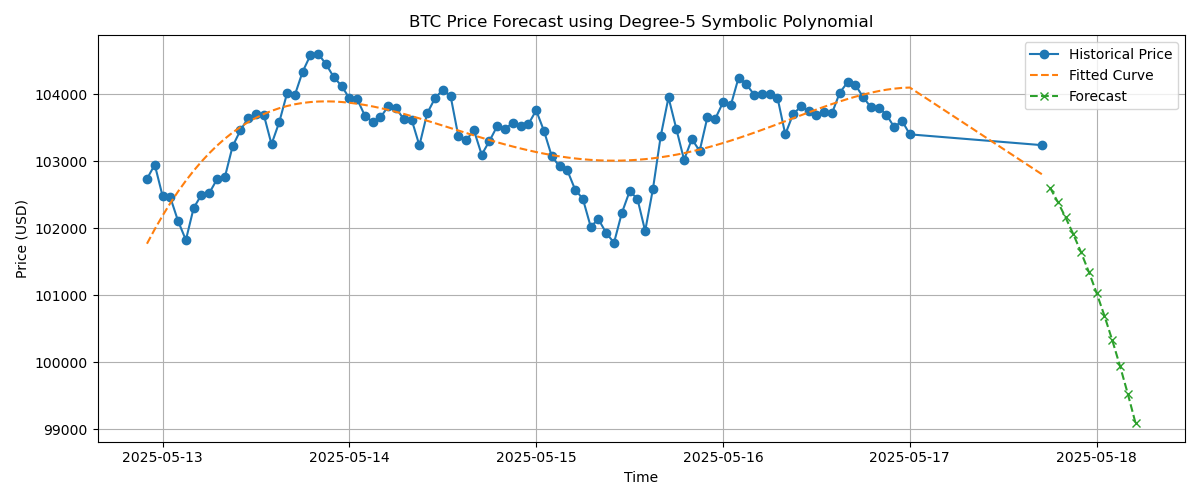

In [2]:
# Plot symbolic forecast
Image('../reports/symbolic_forecast_polydeg5.png')

In [3]:
# Load and display symbolic forecast CSV
try:
    df_sym = pd.read_csv('../reports/symbolic_forecast.csv')
    display(df_sym.head())
except FileNotFoundError:
    print('❌ symbolic_forecast.csv not found.')

,timestamp,actual,symbolic_pred
0,2025-05-12 22:00:00,102732.716667,101766.177212
1,2025-05-12 23:00:00,102946.383333,101982.517907
2,2025-05-13 00:00:00,102481.850000,102184.291978
3,2025-05-13 01:00:00,102457.616667,102371.996406
4,2025-05-13 02:00:00,102103.483333,102546.123418


## 🔶 ARIMA vs SARIMA Forecasting

In [4]:
# Plot comparison chart
Image('../reports/arima_sarima_comparison_plot.png')

FileNotFoundError: No such file or directory: '../reports/arima_sarima_comparison_plot.png'

FileNotFoundError: No such file or directory: '../reports/arima_sarima_comparison_plot.png'

<IPython.core.display.Image object>

In [5]:
# Display metrics
try:
    with open('../reports/arima_sarima_metrics.txt') as f:
        print(f.read())
except FileNotFoundError:
    print('❌ arima_sarima_metrics.txt not found.')

❌ arima_sarima_metrics.txt not found.


In [6]:
# Load and display forecast comparison CSV
try:
    df_compare = pd.read_csv('../reports/arima_vs_sarima_forecast.csv')
    display(df_compare.head())
except FileNotFoundError:
    print('❌ arima_vs_sarima_forecast.csv not found.')

,timestamp,arima_pred,sarima_pred
0,2025-05-12 15:00:00,103427.551546,103652.497290
1,2025-05-12 16:00:00,103475.741038,103484.069391
2,2025-05-12 17:00:00,103494.251204,103520.733532
3,2025-05-12 18:00:00,103489.481418,103653.448658
4,2025-05-12 19:00:00,103487.023114,103827.382339


## ✅ Summary and Learnings
- Symbolic forecasting using SageMath provided interpretable, polynomial models.
- ARIMA worked well for short-term trends but ignored seasonality.
- SARIMA captured hourly fluctuations better and yielded lower error.
- Forecasts were exported and visualized using Python + SageMath stack.

**Next Steps**:
- Introduce Prophet for long-term trend learning
- Use live ingestion for real-time forecasting

# 06_symbolic_forecasting.ipynb
This notebook builds a symbolic polynomial forecasting model using SageMath. You can experiment with:
- Degree of the polynomial
- Number of training samples
- Prediction horizon
- Evaluation accuracy


## 1. Setup and Data Load

In [12]:
from sage.all import *
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
import numpy as np
df = pd.read_csv('../data/bitcoin_timeseries.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').set_index('timestamp')

## 2. Define Hyperparameters

In [13]:
days_to_use = 7
resample_freq = '1h'
samples_to_use = 100
degree = 5
forecast_hours = 12

## 3. Prepare Training Data

In [14]:
# Get last timestamp and build mask manually
last_timestamp = df.index.max()
recent = df.loc[df.index >= last_timestamp - pd.Timedelta(days=int(14))] 

# Resample to hourly, drop missing, reset index
df_model = recent.resample('1h').mean().dropna().reset_index()

# Use only last 100 data points for stability
df_model = df_model.tail(int(100))

# Normalize time: convert to hours, then center around mean
timestamps = df_model['timestamp']
x_vals = [(t - timestamps.iloc[int(0)]).total_seconds() / int(3600) for t in timestamps]
x_mean = sum(x_vals) / len(x_vals)
x_vals = [x - x_mean for x in x_vals]

# Get y-values
y_vals = list(df_model['price_usd'])

print(f"✅ Using {len(x_vals)} normalized points from last 14 days")


✅ Using 100 normalized points from last 14 days


## 4. Symbolic Polynomial Fitting

In [15]:
x = var('x')
params = list(var([f'a{i}' for i in range(degree + 1)]))
model = sum(params[i] * x**i for i in range(degree + 1))
points = list(zip(x_vals, y_vals))
fit = find_fit(points, model, parameters=params, variables=[x], solution_dict=True)
model_fitted = model.subs(fit)
f = lambda t: float(model_fitted.subs(x=t))
y_fit = [f(t) for t in x_vals]

## 5. Forecast Future Values

In [16]:
last_x = float(x_vals[-1])
future_x = [last_x + float(i) for i in range(1, forecast_hours + 1)]
future_preds = [f(t) for t in future_x]
timestamps_list = list(df_model['timestamp'])
last_time = timestamps_list[-1]
future_times = [last_time + timedelta(hours=i) for i in range(1, forecast_hours + 1)]
df_future = pd.DataFrame({
    'timestamp': future_times,
    'predicted_price': future_preds
})

## 6. Plot Historical and Forecasted Values

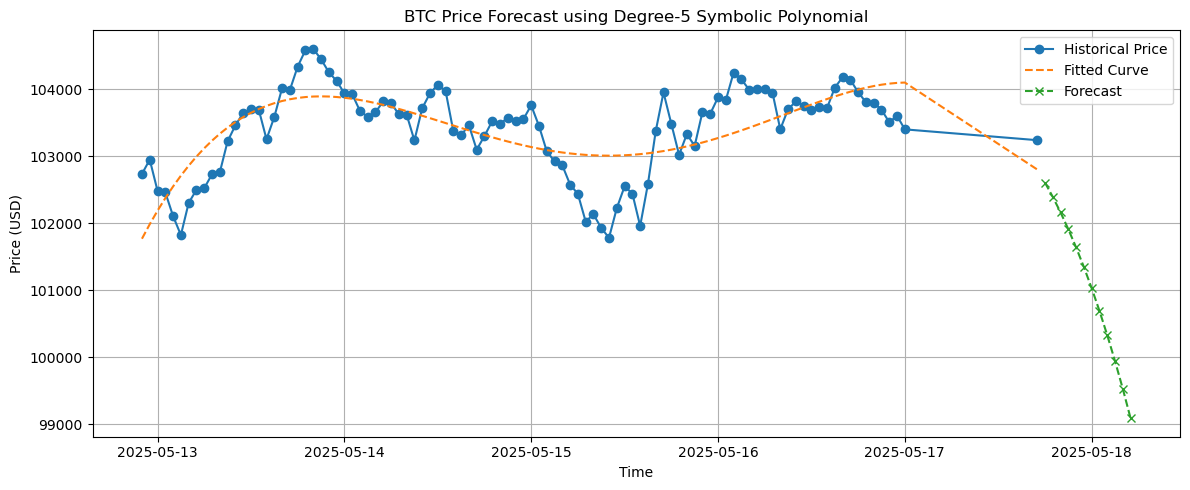

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(df_model['timestamp'], y_vals, label='Historical Price', marker='o')
plt.plot(df_model['timestamp'], y_fit, label='Fitted Curve', linestyle='--')
plt.plot(df_future['timestamp'], df_future['predicted_price'], label='Forecast', marker='x', linestyle='--')
plt.title(f"BTC Price Forecast using Degree-{degree} Symbolic Polynomial")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('../reports/symbolic_forecast_polydeg{}.png'.format(degree))
plt.show()

## 7. Evaluate Fit Accuracy on Training Data

In [18]:
try:
    from sklearn.metrics import mean_absolute_error, mean_squared_error

    # Ensure values are plain Python floats
    y_vals_py = [float(y) for y in y_vals]
    y_fit_py = [float(y) for y in y_fit]

    # Compute MAE and RMSE
    mae = mean_absolute_error(y_vals_py, y_fit_py)
    rmse = (mean_squared_error(y_vals_py, y_fit_py)) ** 0.5  # compatible with older sklearn

    print(f"📏 MAE (Mean Absolute Error): {mae:.2f} USD")
    print(f"📏 RMSE (Root Mean Squared Error): {rmse:.2f} USD")

except ImportError:
    # Manual fallback if sklearn is not installed
    y_vals_py = [float(y) for y in y_vals]
    y_fit_py = [float(y) for y in y_fit]

    mae = sum(abs(y_true - y_pred) for y_true, y_pred in zip(y_vals_py, y_fit_py)) / len(y_vals_py)
    rmse = (sum((y_true - y_pred)**2 for y_true, y_pred in zip(y_vals_py, y_fit_py)) / len(y_vals_py))**0.5

    print(f"📏 MAE (Mean Absolute Error): {mae:.2f} USD")
    print(f"📏 RMSE (Root Mean Squared Error): {rmse:.2f} USD")


📏 MAE (Mean Absolute Error): 375.23 USD
📏 RMSE (Root Mean Squared Error): 472.94 USD


## 8. Print Symbolic Expression

In [19]:
print("\nPolynomial Expression:")
print(model_fitted)
print("\nCoefficients:")
for i in range(degree + 1):
    coef = fit.get(var(f'a{i}'), 0)
    print(f"  a{i} = {coef}")


Polynomial Expression:
-(9.903193248430187e-07)*x^5 - 0.0004338502252459048*x^4 + 0.02222455438382276*x^3 + 0.9838184243998995*x^2 - 25.336895839916508*x + 103142.98166918395

Coefficients:
  a0 = 103142.98166918395
  a1 = -25.336895839916508
  a2 = 0.9838184243998995
  a3 = 0.02222455438382276
  a4 = -0.0004338502252459048
  a5 = -9.903193248430187e-07


In [20]:
df_symbolic = pd.DataFrame({
    'timestamp': df_model['timestamp'].tolist() + df_future['timestamp'].tolist(),
    'actual': y_vals + [None] * len(df_future),
    'symbolic_pred': list(y_fit) + df_future['predicted_price'].tolist()
})
df_symbolic.to_csv('../reports/symbolic_forecast.csv', index=False)

In [21]:
with open('../reports/symbolic_metrics.txt', 'w') as f:
    f.write(f"MAE: {mae:.2f}\n")
    f.write(f"RMSE: {rmse:.2f}\n")

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=3850.770, Time=0.20 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3847.275, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3845.304, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=3845.198, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=3847.820, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=3846.999, Time=0.05 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=3846.901, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=3848.895, Time=0.19 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=3845.134, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=3846.903, Time=0.03 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=3847.001, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=3845.265, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=3848.772, Time=0.09 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 0.731 seconds
📈 ARIMA MAE: 568.49 US

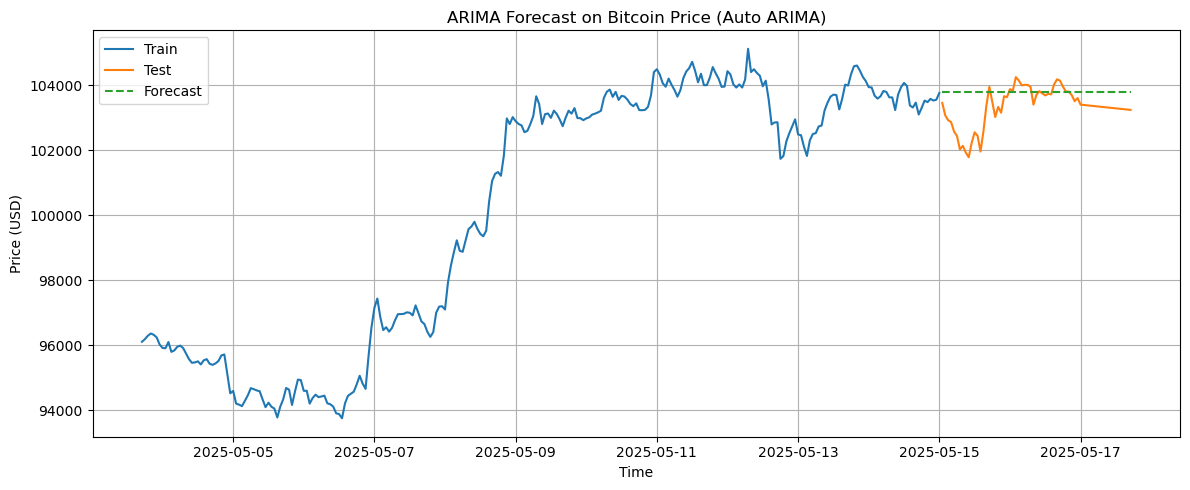

✅ ARIMA forecast saved.


In [2]:
# 07_arima_modeling.ipynb
# ARIMA Forecasting for Bitcoin Time Series using auto_arima

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Monkey patch for scikit-learn < 1.6 compatibility workaround
import sklearn.utils.validation
if hasattr(sklearn.utils.validation, 'force_all_finite'):
    sklearn.utils.validation.ensure_all_finite = sklearn.utils.validation.force_all_finite

# --- 1. Load and Prepare Data ---
df = pd.read_csv("../data/bitcoin_timeseries.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()

# Resample to hourly average
df_hourly = df['price_usd'].resample('1h').mean().dropna()

# Use last N days
days_to_use = 14
hourly_cutoff = df_hourly.index.max() - pd.Timedelta(days=days_to_use)
df_hourly = df_hourly[df_hourly.index >= hourly_cutoff]

# --- 2. Train-Test Split ---
train_size = int(len(df_hourly) * 0.85)
train, test = df_hourly.iloc[:train_size], df_hourly.iloc[train_size:]

# --- 3. Auto ARIMA Model Selection ---
model = auto_arima(train, seasonal=False, trace=True, error_action='ignore', suppress_warnings=True)

# --- 4. Forecast ---
forecast = model.predict(n_periods=len(test))

# --- 5. Evaluate ---
mae = mean_absolute_error(test, forecast)
rmse = mean_squared_error(test, forecast) ** 0.5  # use square root manually for compatibility
print(f"📈 ARIMA MAE: {mae:.2f} USD")
print(f"📈 ARIMA RMSE: {rmse:.2f} USD")

# --- 6. Plot ---
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast, label='Forecast', linestyle='--')
plt.title("ARIMA Forecast on Bitcoin Price (Auto ARIMA)")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("../reports/arima_forecast.png")
plt.show()

# --- 7. Optional: Save Forecast to CSV ---
df_forecast = pd.DataFrame({
    'timestamp': test.index,
    'actual_price': test.values,
    'predicted_price': forecast
})
df_forecast.to_csv("../data/bitcoin_arima_forecast.csv", index=False)
print("✅ ARIMA forecast saved.")

Fitting basic ARIMA(2,1,2)...
Fitting optimized SARIMA(1,1,1)x(1,1,1,24)...


/home/sage/sage/local/var/lib/sage/venv-python3.12.5/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/sage/sage/local/var/lib/sage/venv-python3.12.5/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/sage/sage/local/var/lib/sage/venv-python3.12.5/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/sage/sage/local/var/lib/sage/venv-python3.12.5/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: Val


📊 Basic ARIMA(2,1,2):
MAE: 532.76 USD
RMSE: 688.01 USD

📊 Optimized SARIMA(1,1,1)x(1,1,1,24):
MAE: 1246.68 USD
RMSE: 1423.77 USD


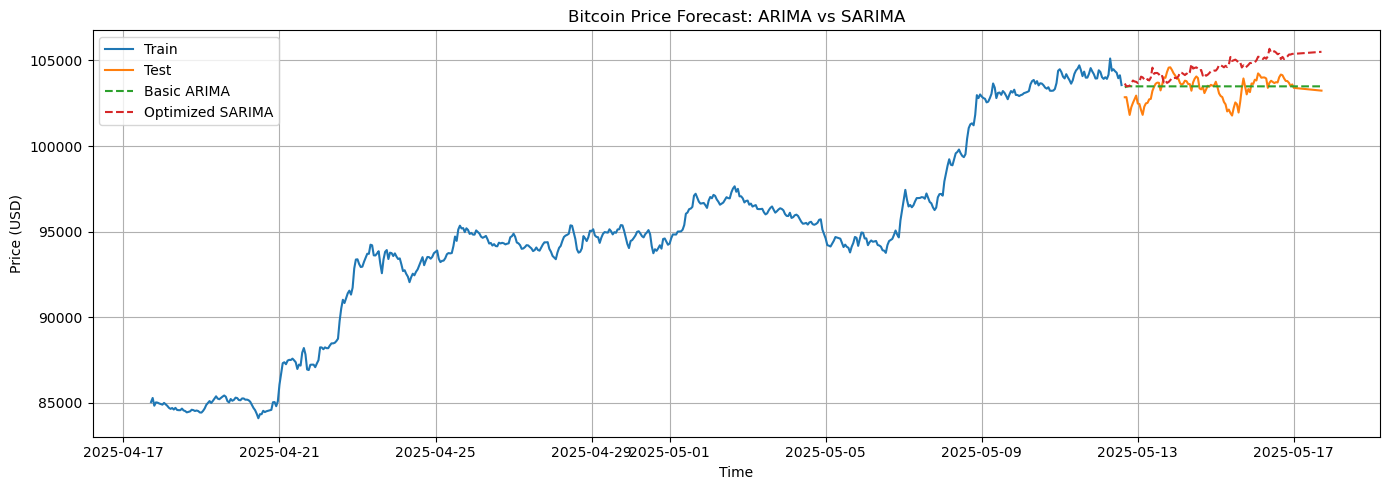

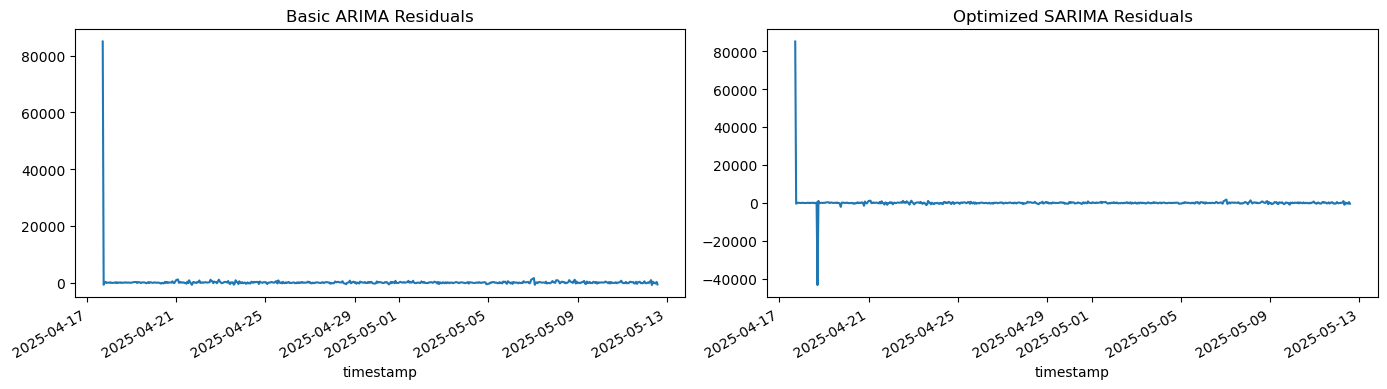

✅ Forecast comparison saved.


In [2]:
# 07_arima_forecasting.ipynb
# Compare simple ARIMA with optimized SARIMA using residual analysis and performance metrics

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Patch for sklearn compatibility
import sklearn.utils.validation
if hasattr(sklearn.utils.validation, 'force_all_finite'):
    sklearn.utils.validation.ensure_all_finite = sklearn.utils.validation.force_all_finite

# --- 1. Load and Prepare Data ---
df = pd.read_csv("../data/bitcoin_timeseries.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()

# Resample to hourly average and filter outliers
df_hourly = df['price_usd'].resample('1h').mean().dropna()
df_hourly = df_hourly[(df_hourly - df_hourly.rolling(24).mean()).abs() < 3 * df_hourly.rolling(24).std()]
df_hourly = df_hourly.dropna()

# Use last 30 days
days_to_use = 30
cutoff = df_hourly.index.max() - pd.Timedelta(days=days_to_use)
df_hourly = df_hourly[df_hourly.index >= cutoff]

# --- 2. Train-Test Split ---
train_size = int(len(df_hourly) * 0.85)
train, test = df_hourly.iloc[:train_size], df_hourly.iloc[train_size:]

# --- 3. Fit Basic ARIMA(2,1,2) ---
print("Fitting basic ARIMA(2,1,2)...")
basic_arima_model = ARIMA(train, order=(2,1,2)).fit()
basic_forecast = basic_arima_model.forecast(steps=len(test))

# --- 4. Fit Optimized SARIMA ---
print("Fitting optimized SARIMA(1,1,1)x(1,1,1,24)...")
opt_sarima_model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,24)).fit(disp=False)
opt_forecast = opt_sarima_model.forecast(steps=len(test))

# --- 5. Evaluate ---
def evaluate(true, pred, label):
    mae = mean_absolute_error(true, pred)
    rmse = mean_squared_error(true, pred) ** 0.5
    print(f"\n📊 {label}:")
    print(f"MAE: {mae:.2f} USD")
    print(f"RMSE: {rmse:.2f} USD")
    return mae, rmse

evaluate(test, basic_forecast, "Basic ARIMA(2,1,2)")
evaluate(test, opt_forecast, "Optimized SARIMA(1,1,1)x(1,1,1,24)")

# --- 6. Plot Forecast Comparison ---
plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, basic_forecast, label='Basic ARIMA', linestyle='--')
plt.plot(test.index, opt_forecast, label='Optimized SARIMA', linestyle='--')
plt.title("Bitcoin Price Forecast: ARIMA vs SARIMA")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("../reports/arima_vs_sarima_comparison.png")
plt.show()

# --- 7. Residual Diagnostics ---
resid_basic = basic_arima_model.resid
resid_opt = opt_sarima_model.resid

plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
resid_basic.plot(title="Basic ARIMA Residuals")
plt.subplot(1,2,2)
resid_opt.plot(title="Optimized SARIMA Residuals")
plt.tight_layout()
plt.savefig("../reports/arima_sarima_residuals.png")
plt.show()

# --- 8. Save Forecasts ---
df_forecast = pd.DataFrame({
    'timestamp': test.index,
    'actual_price': test.values,
    'basic_arima_predicted': basic_forecast,
    'optimized_sarima_predicted': opt_forecast
})
df_forecast.to_csv("../data/bitcoin_forecast_comparison.csv", index=False)
print("✅ Forecast comparison saved.")


In [3]:
from datetime import timedelta

# Get last timestamp from the training data
last_timestamp = train.index[-1]

# Compute forecast horizon
forecast_horizon = len(basic_forecast)

# Generate forecast timestamps
forecast_index = [last_timestamp + timedelta(hours=i) for i in range(1, forecast_horizon + 1)]

# Create and save comparison DataFrame
df_comparison = pd.DataFrame({
    'timestamp': forecast_index,
    'arima_pred': list(basic_forecast),
    'sarima_pred': list(opt_forecast)
})
df_comparison.to_csv('../reports/arima_vs_sarima_forecast.csv', index=False)
